In [1]:
import re
from datetime import datetime
import numpy as np

In [2]:
def extract_data(file_path):
    data = {}
    with open(file_path, 'r') as file:
        for line in file:
            # Match the log line with the required pattern
            match = re.search(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3}) - root - INFO - .*?step:\s+(\d+).*?memory:\s+([\d.]+GiB).*?tps:\s+([\d.]+).*?tflops:\s+([\d.]+)', line)
            if match:
                timestamp = match.group(1)
                step = int(match.group(2))
                memory = match.group(3)
                tps = float(match.group(4))
                tflops = float(match.group(5))
                
                # Only store data for steps 1 to 10
                if 1 <= step <= 10:
                    if step not in data:
                        data[step] = {
                            'timestamp': timestamp,
                            'memory': memory,
                            'tps': tps,
                            'tflops': tflops
                        }
    return data

In [3]:
import csv

# Example usage

def store_data(file_path_base, experiment, file_name, output_file):
    file_path = file_path_base + experiment + "/" + file_name

    result = extract_data(file_path)

    print(experiment)

    for step in sorted(result.keys()):
        print(f"Step {step}: {result[step]}")

    # Calculate per step latency and average latency with standard deviation
    if 4 in result and 10 in result:
        time_format = "%Y-%m-%d %H:%M:%S,%f"
        step_times = []

        for step in range(4, 11):
            if step in result:
                step_time = datetime.strptime(result[step]['timestamp'], time_format)
                step_times.append((step, step_time))

        # Calculate per step latency
        per_step_latencies = []
        for i in range(1, len(step_times)):
            step_diff = step_times[i][0] - step_times[i - 1][0]
            time_diff = (step_times[i][1] - step_times[i - 1][1]).total_seconds()
            latency = time_diff / step_diff
            per_step_latencies.append(latency)
            print(f"Latency between step {step_times[i - 1][0]} and step {step_times[i][0]}: {latency:.3f} seconds")

        # Calculate average latency and standard deviation
        avg_latency = np.mean(per_step_latencies)
        std_latency = np.std(per_step_latencies)
        min_latency = np.min(per_step_latencies)
        print(f"{experiment}, avg step latency: {avg_latency:.3f} seconds, std: {std_latency:.3f} seconds, min: {min_latency:.3f} seconds")
        # Save step latency and standard deviation to a CSV file
        
        with open(output_file, mode='a', newline='') as file:  # Open in append mode
            writer = csv.writer(file)
            writer.writerow([experiment, min_latency, avg_latency, std_latency])

        print(f"Latency data appended to {output_file}")

        print(f"Latency data saved to {output_file}")
    else:
        print("Step 4 or Step 10 data is missing.")

In [4]:
import os

file_path_base = '<path-to-opus>/Opus/torchtitan/opus-test/deepseek-pp-4-tp-4-pm/'


latency = [0, 10, 50, 100, 250, 500, 750, 1000]
experiments =  ["output-opus-l_0-no-ctl"] + [f"output-opus-l_{l}-baseline" for l in latency]
file_name = [
    next(
        (f for f in os.listdir(os.path.join(file_path_base, exp)) if f.startswith("torchrun_nid") and f.endswith(".ans")),
        None
    )
    for exp in experiments
]

output_file = 'latency_results_baseline.csv'

# Write the CSV header if the file does not exist or is empty
# Clean the CSV file before writing
if os.path.exists(output_file):
    with open(output_file, mode='w', newline='') as file:
        file.truncate(0)
if not os.path.exists(output_file) or os.stat(output_file).st_size == 0:
    with open(output_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Experiment', 'Min latency (s)', 'Average Latency (s)', 'Standard Deviation (s)'])
for experiment, file_name in zip(experiments, file_name):
    store_data(file_path_base, experiment, file_name, output_file)

output-opus-l_0-no-ctl
Step 1: {'timestamp': '2026-02-03 16:37:55,667', 'memory': '18.85GiB', 'tps': 19.0, 'tflops': 0.3}
Step 2: {'timestamp': '2026-02-03 16:38:02,986', 'memory': '26.88GiB', 'tps': 140.0, 'tflops': 2.25}
Step 3: {'timestamp': '2026-02-03 16:38:10,301', 'memory': '27.24GiB', 'tps': 140.0, 'tflops': 2.25}
Step 4: {'timestamp': '2026-02-03 16:38:17,546', 'memory': '27.60GiB', 'tps': 141.0, 'tflops': 2.27}
Step 5: {'timestamp': '2026-02-03 16:38:24,793', 'memory': '27.60GiB', 'tps': 141.0, 'tflops': 2.27}
Step 6: {'timestamp': '2026-02-03 16:38:32,225', 'memory': '27.77GiB', 'tps': 138.0, 'tflops': 2.21}
Step 7: {'timestamp': '2026-02-03 16:38:39,465', 'memory': '27.94GiB', 'tps': 141.0, 'tflops': 2.27}
Step 8: {'timestamp': '2026-02-03 16:38:46,703', 'memory': '27.85GiB', 'tps': 142.0, 'tflops': 2.27}
Step 9: {'timestamp': '2026-02-03 16:38:53,938', 'memory': '27.94GiB', 'tps': 142.0, 'tflops': 2.27}
Step 10: {'timestamp': '2026-02-03 16:39:01,219', 'memory': '27.94GiB'

In [7]:
import os

file_path_base = '<path-to-opus>/Opus/torchtitan/opus-test/deepseek-dp-2-pp-2-tp-4-pm/'


latency = [0, 10, 50, 100, 250, 500]
experiments =  ["output-no-controller"] + [f"output-opus-l_{l}-provision-cuda-pre" for l in latency]
file_name = [
    next(
        (f for f in os.listdir(os.path.join(file_path_base, exp)) if f.startswith("torchrun_nid") and f.endswith(".ans")),
        None
    )
    for exp in experiments
]

output_file = 'latency_results_provision-cuda-pre.csv'

# Write the CSV header if the file does not exist or is empty
# Clean the CSV file before writing
if os.path.exists(output_file):
    with open(output_file, mode='w', newline='') as file:
        file.truncate(0)
if not os.path.exists(output_file) or os.stat(output_file).st_size == 0:
    with open(output_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Experiment', 'Min latency (s)', 'Average Latency (s)', 'Standard Deviation (s)'])
for experiment, file_name in zip(experiments, file_name):
    store_data(file_path_base, experiment, file_name, output_file)

output-no-controller
Step 1: {'timestamp': '2026-02-02 02:52:17,950', 'memory': '29.14GiB', 'tps': 45.0, 'tflops': 0.72}
Step 2: {'timestamp': '2026-02-02 02:52:31,654', 'memory': '36.58GiB', 'tps': 75.0, 'tflops': 1.2}
Step 3: {'timestamp': '2026-02-02 02:52:45,317', 'memory': '37.57GiB', 'tps': 75.0, 'tflops': 1.2}
Step 4: {'timestamp': '2026-02-02 02:52:58,808', 'memory': '37.37GiB', 'tps': 76.0, 'tflops': 1.22}
Step 5: {'timestamp': '2026-02-02 02:53:12,124', 'memory': '36.80GiB', 'tps': 77.0, 'tflops': 1.24}
Step 6: {'timestamp': '2026-02-02 02:53:25,739', 'memory': '36.80GiB', 'tps': 75.0, 'tflops': 1.21}
Step 7: {'timestamp': '2026-02-02 02:53:39,251', 'memory': '36.81GiB', 'tps': 76.0, 'tflops': 1.22}
Step 8: {'timestamp': '2026-02-02 02:53:52,631', 'memory': '36.90GiB', 'tps': 77.0, 'tflops': 1.23}
Step 9: {'timestamp': '2026-02-02 02:54:06,073', 'memory': '37.03GiB', 'tps': 76.0, 'tflops': 1.22}
Step 10: {'timestamp': '2026-02-02 02:54:19,567', 'memory': '36.90GiB', 'tps': 76

The previous result show that this experiment has 12 reconfigurations per step

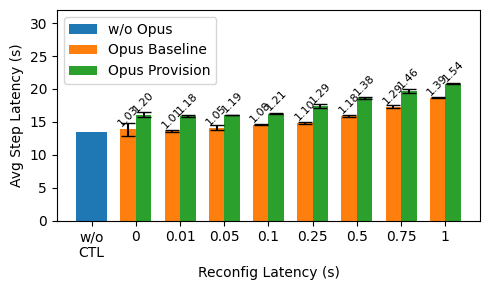

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure the experiments are plotted in the specified order
experiments_1 = [
    'output-opus-l_0-baseline',
    'output-opus-l_10-baseline',
    'output-opus-l_50-baseline',
    'output-opus-l_100-baseline',
    'output-opus-l_250-baseline',
    'output-opus-l_500-baseline',
    'output-opus-l_750-baseline',
    'output-opus-l_1000-baseline',
]

experiments_2 = [
    'output-opus-l_0-provision',
    'output-opus-l_10-provision',
    'output-opus-l_50-provision',
    'output-opus-l_100-provision',
    'output-opus-l_250-provision',
    'output-opus-l_500-provision',
    'output-opus-l_750-provision',
    'output-opus-l_1000-provision',
]

xlabels = ['w/o\nCTL', '0', '0.01', '0.05', '0.1', '0.25', '0.5', '0.75', '1']

baseline = 13.459833333333334
estimated = [baseline] + [baseline + 6 * 0.001 * l for l in latency]

# Read the first CSV file
output_file = 'latency_results_baseline.csv'
data = pd.read_csv(output_file)

# Group by Experiment and calculate the mean of Average Latency and Standard Deviation
data = data[data['Experiment'].isin(experiments_1)].copy()

data['Experiment'] = pd.Categorical(
    data['Experiment'],
    categories=experiments_1,
    ordered=True
)
grouped_data = data.sort_values('Experiment')
grouped_data = data.sort_values('Experiment')

# Read the second CSV file
output_file_2 = 'latency_results_provision.csv'
data_2 = pd.read_csv(output_file_2)
data_2 = data_2[data_2['Experiment'].isin(experiments_2)].copy()

# Group by Experiment and calculate the mean of Average Latency and Standard Deviation for the second file
data_2['Experiment'] = pd.Categorical(data_2['Experiment'], categories=experiments_2, ordered=True)
grouped_data_2 = data_2.sort_values('Experiment')

# Plot the data
plt.figure(figsize=(5, 3))
x = np.arange(len(xlabels))

bar_width = 0.35

plt.bar(
    x[0],
    baseline,
    bar_width * 2,
    label='w/o Opus'
)

# --------------------
# Remaining 10 categories: paired bars
# --------------------
plt.bar(
    x[1:] - bar_width / 2,
    grouped_data['Average Latency (s)'],
    bar_width,
    yerr=grouped_data['Standard Deviation (s)'],
    capsize=5,
    label='Opus Baseline'
)

plt.bar(
    x[1:] + bar_width / 2,
    grouped_data_2['Average Latency (s)'],
    bar_width,
    yerr=grouped_data_2['Standard Deviation (s)'],
    capsize=5,
    label='Opus Provision'
)

# Add a 1.x overhead on the top number
for i, (baseline_latency, provision_latency) in enumerate(zip(grouped_data['Average Latency (s)'], grouped_data_2['Average Latency (s)'])):
    plt.text(
        x[i + 1] - bar_width / 2,
        baseline_latency + 0.1,
        f"{baseline_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45  # Tilt the number by 45 degrees
    )
    plt.text(
        x[i + 1] + bar_width / 2,
        provision_latency + 0.1,
        f"{provision_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45  # Tilt the number by 45 degrees
    )

# plt.plot(
#     xlabels, 
#     estimated, 
#     marker='o', 
#     markersize=4,  # Make the dot smaller
#     linestyle='dashed', 
#     linewidth=1,  # Make the line thinner
#     label='Estimated'
# )
# Add labels and legend
plt.xticks(x, xlabels)
plt.xlabel('Reconfig Latency (s)')
plt.ylabel('Avg Step Latency (s)')
plt.ylim(0, 32)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

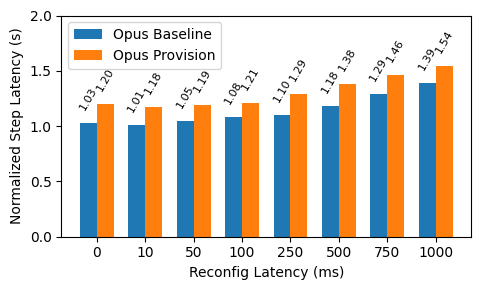

In [9]:


plt.figure(figsize=(5, 3))

xlabels = ['0', '10', '50', '100', '250', '500', '750', '1000']
x = np.arange(len(xlabels))

# plt.bar(
#     x[0],
#     baseline,
#     bar_width * 2,
#     label='w/o Opus'
# )

# --------------------
# Remaining 10 categories: paired bars
# --------------------
plt.bar(
    x - bar_width / 2,
    grouped_data['Average Latency (s)'] / baseline,
    bar_width,
    # yerr=grouped_data['Standard Deviation (s)'],
    capsize=5,
    label='Opus Baseline'
)

plt.bar(
    x + bar_width / 2,
    grouped_data_2['Average Latency (s)'] / baseline,
    bar_width,
    # yerr=grouped_data_2['Standard Deviation (s)'],
    capsize=5,
    label='Opus Provision'
)

# Add a 1.x overhead on the top number
for i, (baseline_latency, provision_latency) in enumerate(zip(grouped_data['Average Latency (s)'], grouped_data_2['Average Latency (s)'])):
    plt.text(
        x[i] - bar_width / 2,
        baseline_latency / baseline + 0.1,
        f"{baseline_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=60  # Tilt the number by 45 degrees
    )
    plt.text(
        x[i] + bar_width / 2,
        provision_latency / baseline + 0.1,
        f"{provision_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=60  # Tilt the number by 45 degrees
    )

# plt.plot(
#     xlabels, 
#     estimated, 
#     marker='o', 
#     markersize=4,  # Make the dot smaller
#     linestyle='dashed', 
#     linewidth=1,  # Make the line thinner
#     label='Estimated'
# )
# Add labels and legend
plt.xticks(x, xlabels)
plt.xlabel('Reconfig Latency (ms)')
plt.ylabel('Normalized Step Latency (s)')
plt.ylim(0, 2)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#TODO I recommend changing X axis to milliseconds and going up to 500 milliseconds